# Event 9 — waveform approximant comparison

Cell 1: load injection params & print. Cells 2+: generate, project, save NPZ. Last cell: overlay all waveforms with merger/taper markers.

In [1]:
# Cell 1 — load event_0009 injection parameters
import os
os.environ["LAL_DATA_PATH"] = "/scratch/gpfs/ANDREASB/lalsuite-extra/lalsuite-waveform-data/waveform_data"
import json, numpy as np, bilby
from pathlib import Path

EVENT_NAME = "event_0009"
POP_OUTDIR = Path("/scratch/gpfs/ANDREASB/fy6204/GW/Workspace/outputs/outdir_population_exactfd")

with open(POP_OUTDIR / "catalog_config.json") as f:
    catalog = json.load(f)

ifo_files = catalog["ifo_files"]
waveform_arguments = dict(catalog["waveform_arguments"])
sampling_frequency = catalog.get("sampling_frequency", 8192.0)
fmin = waveform_arguments.get("minimum_frequency", 10.0)
fref = waveform_arguments.get("reference_frequency", fmin)

with open(POP_OUTDIR / EVENT_NAME / "meta.json") as f:
    meta = json.load(f)

inj = dict(meta["injection_parameters"])
data_segment = meta["data_segment"]
duration = int(data_segment["duration"])
start_time = float(data_segment["start_time"])
signal_info = meta["exact_signal_file"]

exact_npz = np.load(POP_OUTDIR / EVENT_NAME / signal_info["filename"])
exact_freq = exact_npz["frequency_array"].astype(np.float64)
exact_signals = {d: exact_npz[k].astype(np.complex128)
                 for d, k in signal_info["detector_signal_keys"].items()}

ifos = bilby.gw.detector.InterferometerList([
    bilby.gw.detector.load_interferometer(x) for x in ifo_files])
for ifo in ifos:
    ifo.minimum_frequency = fmin
ifos.set_strain_data_from_power_spectral_densities(
    sampling_frequency=sampling_frequency, duration=duration, start_time=start_time)
for ifo in ifos:
    ifo.strain_data.frequency_domain_strain += exact_signals[ifo.name]

frequency_array = ifos[0].frequency_array.astype(np.float64)
detectors = [ifo.name for ifo in ifos]

# print params
print("=== Injection parameters ===")
for k in ["mass_1", "mass_2", "luminosity_distance", "theta_jn", "phase",
          "ra", "dec", "psi", "geocent_time",
          "chi_1", "chi_2", "lambda_1", "lambda_2"]:
    print(f"  {k:25s} = {inj.get(k, '<missing>')}")

print(f"\n=== Grid ===")
print(f"  duration={duration}, fs={sampling_frequency}, fmin={fmin}, fref={fref}")
print(f"  detectors={detectors}, nfreq={len(frequency_array)}")
print(f"  df={frequency_array[1]-frequency_array[0]:.6f}, f_max={frequency_array[-1]:.1f}")

print(f"\n=== Exact signal ===")
for d, h in exact_signals.items():
    m = (exact_freq >= 1300) & (exact_freq <= 2100) & (np.abs(h) > 0)
    if np.any(m):
        print(f"  {d}: last nonzero={exact_freq[m][-1]:.1f} Hz, min|h|={np.min(np.abs(h[m])):.2e}")


=== Injection parameters ===
  mass_1                    = 1.6487467646511036
  mass_2                    = 1.5132501613829283
  luminosity_distance       = 705.2414369469649
  theta_jn                  = 0.7279410132283103
  phase                     = 0.19034697272855164
  ra                        = 2.666402504897264
  dec                       = -0.7710971761914536
  psi                       = 0.5627433053850376
  geocent_time              = 1126300602.413
  chi_1                     = 0.001267429399038221
  chi_2                     = -0.001603615625657113
  lambda_1                  = 430.78128630577476
  lambda_2                  = 725.9588652003506

=== Grid ===
  duration=1024, fs=8192.0, fmin=10.0, fref=10.0
  detectors=['CE-B20', 'CE-A40'], nfreq=4194305
  df=0.000977, f_max=4096.0

=== Exact signal ===
  CE-A40: last nonzero=1886.7 Hz, min|h|=3.17e-46
  CE-B20: last nonzero=1886.7 Hz, min|h|=1.95e-46


## 2. IMRPhenomXP_NRTidalv3 (production)

In [ ]:
approximant = "IMRPhenomXP_NRTidalv3"

wg = bilby.gw.WaveformGenerator(
    duration=duration, sampling_frequency=sampling_frequency,
    frequency_domain_source_model=bilby.gw.source.lal_binary_neutron_star,
    parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_neutron_star_parameters,
    waveform_arguments=dict(waveform_approximant=approximant,
                            minimum_frequency=fmin, reference_frequency=fref),
)
pols = wg.frequency_domain_strain(parameters=inj)
hp, hc = np.asarray(pols["plus"]), np.asarray(pols["cross"])

det_wf = {ifo.name: np.asarray(ifo.get_detector_response(pols, inj)) for ifo in ifos}

outdir = Path("/scratch/gpfs/ANDREASB/fy6204/GW/Workspace/event9_waveform_approximant")
outdir.mkdir(parents=True, exist_ok=True)
np.savez_compressed(outdir / f"event9_{approximant}.npz",
    frequency=frequency_array, h_plus=hp, h_cross=hc,
    **{f"h_{d}": det_wf[d] for d in detectors})

print(f"approximant: {approximant}")
for d in detectors:
    h = det_wf[d]
    m = (frequency_array >= 1300) & (frequency_array <= 2100) & (np.abs(h) > 0)
    if np.any(m):
        print(f"  {d}: last nonzero={frequency_array[m][-1]:.1f} Hz, min|h|={np.min(np.abs(h[m])):.2e}")


00:58 bilby INFO    : Waveform generator instantiated: WaveformGenerator(duration=1024, sampling_frequency=8192.0, start_time=0, frequency_domain_source_model=bilby.gw.source.lal_binary_neutron_star, time_domain_source_model=None, parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_neutron_star_parameters, waveform_arguments={'waveform_approximant': 'IMRPhenomXP_NRTidalv3', 'minimum_frequency': 10.0, 'reference_frequency': 10.0})


approximant: IMRPhenomXP_NRTidalv3
  CE-B20: last nonzero=1886.7 Hz, min|h|=1.95e-46
  CE-A40: last nonzero=1886.7 Hz, min|h|=3.17e-46


## 3. IMRPhenomXP_NRTidalv2

In [ ]:
approximant = "IMRPhenomXP_NRTidalv2"

wg = bilby.gw.WaveformGenerator(
    duration=duration, sampling_frequency=sampling_frequency,
    frequency_domain_source_model=bilby.gw.source.lal_binary_neutron_star,
    parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_neutron_star_parameters,
    waveform_arguments=dict(waveform_approximant=approximant,
                            minimum_frequency=fmin, reference_frequency=fref),
)
pols = wg.frequency_domain_strain(parameters=inj)
hp, hc = np.asarray(pols["plus"]), np.asarray(pols["cross"])

det_wf = {ifo.name: np.asarray(ifo.get_detector_response(pols, inj)) for ifo in ifos}

outdir = Path("/scratch/gpfs/ANDREASB/fy6204/GW/Workspace/event9_waveform_approximant")
outdir.mkdir(parents=True, exist_ok=True)
np.savez_compressed(outdir / f"event9_{approximant}.npz",
    frequency=frequency_array, h_plus=hp, h_cross=hc,
    **{f"h_{d}": det_wf[d] for d in detectors})

print(f"approximant: {approximant}")
for d in detectors:
    h = det_wf[d]
    m = (frequency_array >= 1300) & (frequency_array <= 2100) & (np.abs(h) > 0)
    if np.any(m):
        print(f"  {d}: last nonzero={frequency_array[m][-1]:.1f} Hz, min|h|={np.min(np.abs(h[m])):.2e}")


00:59 bilby INFO    : Waveform generator instantiated: WaveformGenerator(duration=1024, sampling_frequency=8192.0, start_time=0, frequency_domain_source_model=bilby.gw.source.lal_binary_neutron_star, time_domain_source_model=None, parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_neutron_star_parameters, waveform_arguments={'waveform_approximant': 'IMRPhenomXP_NRTidalv2', 'minimum_frequency': 10.0, 'reference_frequency': 10.0})


approximant: IMRPhenomXP_NRTidalv2
  CE-B20: last nonzero=1847.2 Hz, min|h|=3.78e-43
  CE-A40: last nonzero=1847.2 Hz, min|h|=6.14e-43


## 4. IMRPhenomXAS_NRTidalv3

In [ ]:
approximant = "IMRPhenomXAS_NRTidalv3"

wg = bilby.gw.WaveformGenerator(
    duration=duration, sampling_frequency=sampling_frequency,
    frequency_domain_source_model=bilby.gw.source.lal_binary_neutron_star,
    parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_neutron_star_parameters,
    waveform_arguments=dict(waveform_approximant=approximant,
                            minimum_frequency=fmin, reference_frequency=fref),
)
pols = wg.frequency_domain_strain(parameters=inj)
hp, hc = np.asarray(pols["plus"]), np.asarray(pols["cross"])

det_wf = {ifo.name: np.asarray(ifo.get_detector_response(pols, inj)) for ifo in ifos}

outdir = Path("/scratch/gpfs/ANDREASB/fy6204/GW/Workspace/event9_waveform_approximant")
outdir.mkdir(parents=True, exist_ok=True)
np.savez_compressed(outdir / f"event9_{approximant}.npz",
    frequency=frequency_array, h_plus=hp, h_cross=hc,
    **{f"h_{d}": det_wf[d] for d in detectors})

print(f"approximant: {approximant}")
for d in detectors:
    h = det_wf[d]
    m = (frequency_array >= 1300) & (frequency_array <= 2100) & (np.abs(h) > 0)
    if np.any(m):
        print(f"  {d}: last nonzero={frequency_array[m][-1]:.1f} Hz, min|h|={np.min(np.abs(h[m])):.2e}")


01:00 bilby INFO    : Waveform generator instantiated: WaveformGenerator(duration=1024, sampling_frequency=8192.0, start_time=0, frequency_domain_source_model=bilby.gw.source.lal_binary_neutron_star, time_domain_source_model=None, parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_neutron_star_parameters, waveform_arguments={'waveform_approximant': 'IMRPhenomXAS_NRTidalv3', 'minimum_frequency': 10.0, 'reference_frequency': 10.0})


approximant: IMRPhenomXAS_NRTidalv3
  CE-B20: last nonzero=1886.7 Hz, min|h|=1.95e-46
  CE-A40: last nonzero=1886.7 Hz, min|h|=3.17e-46


## 5. IMRPhenomXP_NRTidalv3_nodyn

In [ ]:
# change to GW_nodyn env
approximant = "IMRPhenomXP_NRTidalv3_nodyn"  # no dynamical tides (GW_nodyn env)
wg = bilby.gw.WaveformGenerator(
    duration=duration, sampling_frequency=sampling_frequency,
    frequency_domain_source_model=bilby.gw.source.lal_binary_neutron_star,
    parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_neutron_star_parameters,
    waveform_arguments=dict(waveform_approximant="IMRPhenomXP_NRTidalv3",
                            minimum_frequency=fmin, reference_frequency=fref),
)
pols = wg.frequency_domain_strain(parameters=inj)
hp, hc = np.asarray(pols["plus"]), np.asarray(pols["cross"])

det_wf = {ifo.name: np.asarray(ifo.get_detector_response(pols, inj)) for ifo in ifos}

outdir = Path("/scratch/gpfs/ANDREASB/fy6204/GW/Workspace/event9_waveform_approximant")
outdir.mkdir(parents=True, exist_ok=True)
np.savez_compressed(outdir / f"event9_{approximant}.npz",
    frequency=frequency_array, h_plus=hp, h_cross=hc,
    **{f"h_{d}": det_wf[d] for d in detectors})

print(f"approximant: {approximant}")
for d in detectors:
    h = det_wf[d]
    m = (frequency_array >= 1300) & (frequency_array <= 2100) & (np.abs(h) > 0)
    if np.any(m):
        print(f"  {d}: last nonzero={frequency_array[m][-1]:.1f} Hz, min|h|={np.min(np.abs(h[m])):.2e}")


01:02 bilby INFO    : Waveform generator instantiated: WaveformGenerator(duration=1024, sampling_frequency=8192.0, start_time=0, frequency_domain_source_model=bilby.gw.source.lal_binary_neutron_star, time_domain_source_model=None, parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_neutron_star_parameters, waveform_arguments={'waveform_approximant': 'IMRPhenomXP_NRTidalv3', 'minimum_frequency': 10.0, 'reference_frequency': 10.0})
/home/fy6204/.conda/envs/GW_nodyn/lib/python3.11/site-packages/lalsimulation/lalsimulation.py:11: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppr

approximant: IMRPhenomXP_NRTidalv3_nodyn
  CE-B20: last nonzero=1886.7 Hz, min|h|=1.95e-46
  CE-A40: last nonzero=1886.7 Hz, min|h|=3.17e-46


## 6. SEOBNRv5_ROM_NRTidalv3

In [ ]:
approximant = "SEOBNRv5_ROM_NRTidalv3"

wg = bilby.gw.WaveformGenerator(
    duration=duration, sampling_frequency=sampling_frequency,
    frequency_domain_source_model=bilby.gw.source.lal_binary_neutron_star,
    parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_neutron_star_parameters,
    waveform_arguments=dict(waveform_approximant=approximant,
                            minimum_frequency=fmin, reference_frequency=fref),
)
pols = wg.frequency_domain_strain(parameters=inj)
hp, hc = np.asarray(pols["plus"]), np.asarray(pols["cross"])

det_wf = {ifo.name: np.asarray(ifo.get_detector_response(pols, inj)) for ifo in ifos}

outdir = Path("/scratch/gpfs/ANDREASB/fy6204/GW/Workspace/event9_waveform_approximant")
outdir.mkdir(parents=True, exist_ok=True)
np.savez_compressed(outdir / f"event9_{approximant}.npz",
    frequency=frequency_array, h_plus=hp, h_cross=hc,
    **{f"h_{d}": det_wf[d] for d in detectors})

print(f"approximant: {approximant}")
for d in detectors:
    h = det_wf[d]
    m = (frequency_array >= 1300) & (frequency_array <= 2100) & (np.abs(h) > 0)
    if np.any(m):
        print(f"  {d}: last nonzero={frequency_array[m][-1]:.1f} Hz, min|h|={np.min(np.abs(h[m])):.2e}")


01:03 bilby INFO    : Waveform generator instantiated: WaveformGenerator(duration=1024, sampling_frequency=8192.0, start_time=0, frequency_domain_source_model=bilby.gw.source.lal_binary_neutron_star, time_domain_source_model=None, parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_neutron_star_parameters, waveform_arguments={'waveform_approximant': 'SEOBNRv5_ROM_NRTidalv3', 'minimum_frequency': 10.0, 'reference_frequency': 10.0})


approximant: SEOBNRv5_ROM_NRTidalv3
  CE-B20: last nonzero=1877.4 Hz, min|h|=3.24e-43
  CE-A40: last nonzero=1877.4 Hz, min|h|=5.26e-43


## 7. IMRPhenomXP_NRTidalv3 with multibanding disabled

Waveform expert suggestion: set `PhenomXHMThresholdMband = 0` to disable the PhenomX multibanding path that can interact badly with the Planck taper. Re-run this cell, then re-run the overlay plot cell below.

In [3]:
# IMRPhenomXP_NRTidalv3 with PhenomX multibanding disabled
# Suggested by waveform expert: the bumps may come from multibanding interacting with the Planck taper.

import traceback

approximant = "IMRPhenomXP_NRTidalv3"
approximant_label = "IMRPhenomXP_NRTidalv3_PhenomXHMThresholdMband0"

waveform_arguments_mband_off = dict(
    waveform_approximant=approximant,
    minimum_frequency=fmin,
    reference_frequency=fref,
    PhenomXHMThresholdMband=0,
)

try:
    wg = bilby.gw.WaveformGenerator(
        duration=duration,
        sampling_frequency=sampling_frequency,
        frequency_domain_source_model=bilby.gw.source.lal_binary_neutron_star,
        parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_neutron_star_parameters,
        waveform_arguments=waveform_arguments_mband_off,
    )

    pols = wg.frequency_domain_strain(parameters=inj)
    hp, hc = np.asarray(pols["plus"]), np.asarray(pols["cross"])
    det_wf = {ifo.name: np.asarray(ifo.get_detector_response(pols, inj)) for ifo in ifos}

    outdir = Path("/scratch/gpfs/ANDREASB/fy6204/GW/Workspace/event9_waveform_approximant")
    outdir.mkdir(parents=True, exist_ok=True)
    outpath = outdir / f"event9_{approximant_label}.npz"

    np.savez_compressed(
        outpath,
        frequency=frequency_array,
        h_plus=hp,
        h_cross=hc,
        approximant=np.array(approximant),
        approximant_label=np.array(approximant_label),
        waveform_arguments_json=np.array(json.dumps(waveform_arguments_mband_off, sort_keys=True)),
        **{f"h_{d}": det_wf[d] for d in detectors},
    )

    print(f"approximant: {approximant}")
    print(f"label saved as: {approximant_label}")
    print(f"waveform_arguments: {waveform_arguments_mband_off}")
    print(f"saved: {outpath}")

    for d in detectors:
        h = det_wf[d]
        m = (frequency_array >= 1300) & (frequency_array <= 2100) & (np.abs(h) > 0)
        if np.any(m):
            print(
                f"  {d}: last nonzero={frequency_array[m][-1]:.1f} Hz, "
                f"min|h|={np.min(np.abs(h[m])):.2e}"
            )
        else:
            print(f"  {d}: no nonzero samples between 1300 and 2100 Hz")

except Exception as e:
    print("Waveform generation failed cleanly.")
    print(f"approximant: {approximant}")
    print(f"waveform_arguments: {waveform_arguments_mband_off}")
    print(f"error type: {type(e).__name__}")
    print(f"error message: {e}")
    traceback.print_exc()



11:54 bilby INFO    : Waveform generator instantiated: WaveformGenerator(duration=1024, sampling_frequency=8192.0, start_time=0, frequency_domain_source_model=bilby.gw.source.lal_binary_neutron_star, time_domain_source_model=None, parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_neutron_star_parameters, waveform_arguments={'waveform_approximant': 'IMRPhenomXP_NRTidalv3', 'minimum_frequency': 10.0, 'reference_frequency': 10.0, 'PhenomXHMThresholdMband': 0})
/home/fy6204/.conda/envs/GW/lib/python3.11/site-packages/lalsimulation/lalsimulation.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyt

approximant: IMRPhenomXP_NRTidalv3
label saved as: IMRPhenomXP_NRTidalv3_PhenomXHMThresholdMband0
waveform_arguments: {'waveform_approximant': 'IMRPhenomXP_NRTidalv3', 'minimum_frequency': 10.0, 'reference_frequency': 10.0, 'PhenomXHMThresholdMband': 0}
saved: /scratch/gpfs/ANDREASB/fy6204/GW/Workspace/event9_waveform_approximant/event9_IMRPhenomXP_NRTidalv3_PhenomXHMThresholdMband0.npz
  CE-B20: last nonzero=1877.4 Hz, min|h|=3.29e-43
  CE-A40: last nonzero=1877.4 Hz, min|h|=5.34e-43


## 5. Overlay plot with merger/taper markers

v3 f_mrg=1571.4, 1.2*f_mrg=1885.7
v2 f_mrg=1540.3, 1.2*f_mrg=1848.4


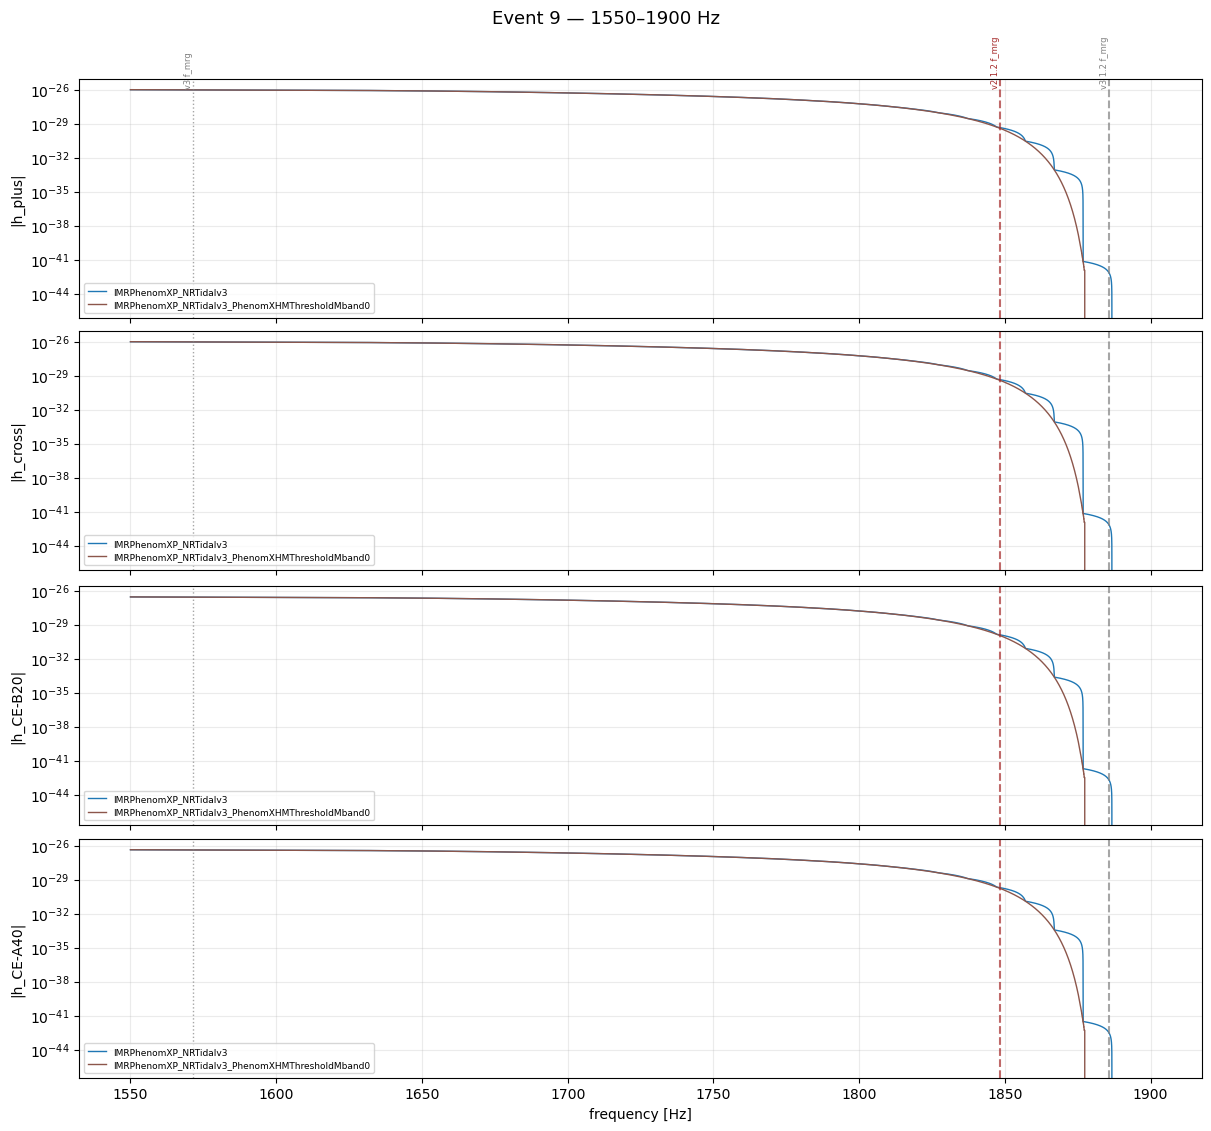

Saved: /scratch/gpfs/ANDREASB/fy6204/GW/Workspace/event9_waveform_approximant/comparison_1550_1900Hz.png


In [5]:
# Overlay all saved waveforms with merger/taper frequency markers
import matplotlib.pyplot as plt
import lal, lalsimulation as lalsim

outdir = Path("/scratch/gpfs/ANDREASB/fy6204/GW/Workspace/event9_waveform_approximant")
npz_files = sorted(outdir.glob("event9_*.npz"))
assert npz_files, "No NPZ files found. Run generation cells first."

# tunable frequency range
F_LEFT  = 1550.0
F_RIGHT = 1900.0

# merger frequencies
mtot = inj["mass_1"] + inj["mass_2"]
q = inj["mass_1"] / inj["mass_2"]
lam1, lam2 = inj["lambda_1"], inj["lambda_2"]
chi1, chi2 = inj["chi_1"], inj["chi_2"]

f_mrg_v3 = lalsim.SimNRTunedTidesMergerFrequency_v3(mtot, lam1, lam2, q, chi1, chi2)
kappa2T = lalsim.SimNRTunedTidesComputeKappa2T(
    inj["mass_1"]*lal.MSUN_SI, inj["mass_2"]*lal.MSUN_SI, lam1, lam2)
f_mrg_v2 = lalsim.SimNRTunedTidesMergerFrequency(mtot, kappa2T, q)

taper_lines = [
    (f_mrg_v3,     "grey",  ":",  1.0, "v3 f_mrg"),
    (1.2*f_mrg_v3, "grey",  "--", 1.5, "v3 1.2 f_mrg (taper->0)"),
    (f_mrg_v2,     "brown", ":",  1.0, "v2 f_mrg"),
    (1.2*f_mrg_v2, "brown", "--", 1.5, "v2 1.2 f_mrg (taper->0)"),
]
print(f"v3 f_mrg={f_mrg_v3:.1f}, 1.2*f_mrg={1.2*f_mrg_v3:.1f}")
print(f"v2 f_mrg={f_mrg_v2:.1f}, 1.2*f_mrg={1.2*f_mrg_v2:.1f}")

wave_keys = ["h_plus", "h_cross"] + [f"h_{d}" for d in detectors]
colors = plt.cm.tab10(np.linspace(0, 1, len(npz_files)+1))

fig, axes = plt.subplots(len(wave_keys), 1, figsize=(12, 2.8*len(wave_keys)),
                         sharex=True, constrained_layout=True)

for row, key in enumerate(wave_keys):
    ax = axes[row]
    for i, npz_path in enumerate(npz_files):
        data = np.load(npz_path, allow_pickle=True)
        if key not in data: continue
        f = data["frequency"]
        m = (f >= F_LEFT) & (f <= F_RIGHT)
        if not np.any(m): continue
        label = npz_path.stem.replace("event9_", "")
        ax.semilogy(f[m], np.abs(data[key][m]), lw=1.0, color=colors[i], label=label)

    # exact signal (detector rows only)
    ek = f"h_{key.replace('h_', '')}"
    if ek in exact_signals and row >= 2:
        m = (exact_freq >= F_LEFT) & (exact_freq <= F_RIGHT)
        ax.semilogy(exact_freq[m], np.abs(exact_signals[ek][m]),
                    lw=1.2, ls="--", color="black", label="exact saved", alpha=0.7)

    for f_val, color, ls, lw, label in taper_lines:
        if F_LEFT <= f_val <= F_RIGHT:
            ax.axvline(f_val, ls=ls, lw=lw, color=color, alpha=0.7)
            if row == 0:
                ax.text(f_val, ax.get_ylim()[1]*0.15, label.split(" (")[0],
                        rotation=90, fontsize=6, color=color, va="bottom", ha="right")
    ax.set_ylabel(f"|{key}|")
    ax.legend(fontsize=6.5, loc="lower left")
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel("frequency [Hz]")
fig.suptitle(f"Event 9 — {F_LEFT:.0f}–{F_RIGHT:.0f} Hz", fontsize=13)
outpath = outdir / f"comparison_{F_LEFT:.0f}_{F_RIGHT:.0f}Hz.png"
fig.savefig(outpath, dpi=300)
plt.show()
print(f"Saved: {outpath}")
